# firstlook — the showcase

From a raw dataframe to **models worth trying**, **the right charts**, and **a scored baseline** — in one call. Below, the whole arc runs on three real datasets, next to the boilerplate it replaces.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import plotly.io as pio; pio.renderers.default = 'notebook_connected'
import firstlook as fl

## 1 · Breast cancer — the old way, then one line

A real diagnostic set: 569 samples, 30 numeric features, malignant vs benign. Here's the opening you'd normally type by hand.

(569, 31)
target
benign       357
malignant    212
Name: count, dtype: int64


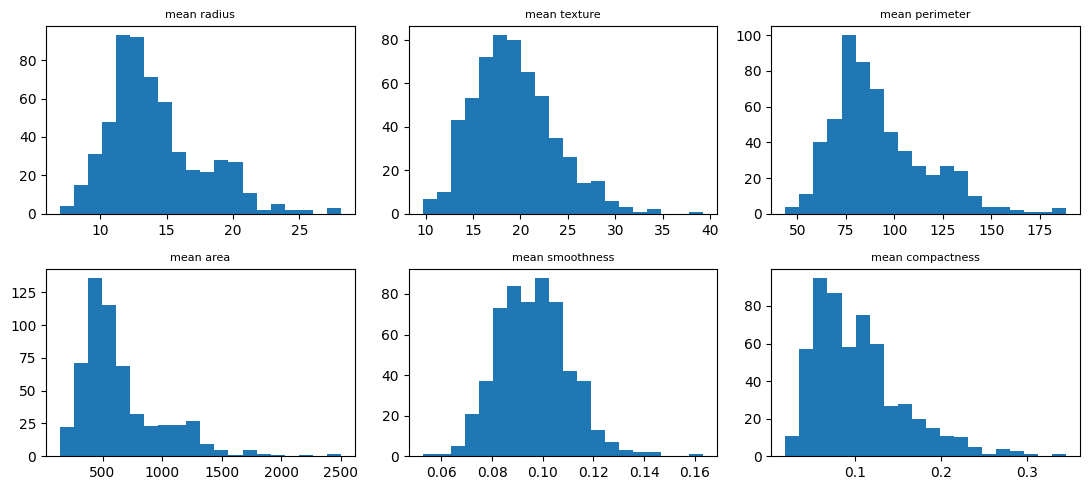

In [2]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True).frame
bc['target'] = bc['target'].map({0: 'malignant', 1: 'benign'})

import matplotlib.pyplot as plt
print(bc.shape)
print(bc['target'].value_counts())
fig, axes = plt.subplots(2, 3, figsize=(11, 5))
for ax, col in zip(axes.ravel(), bc.columns[:6]):
    ax.hist(bc[col], bins=20); ax.set_title(col, fontsize=8)
plt.tight_layout(); plt.show()

Six static histograms, no model, no recommendation — and 25 more features still unlooked-at. You'd still have to decide it's classification, recall which models fit, scale the features, choose a metric, and write the cross-validation loop.

The same dataset through firstlook:

In [3]:
r = fl.at(bc, target='target', fit=True, title='Breast cancer — diagnosis')

One line. It knew the task, ranked the models, drew the four charts that matter, and returned a cross-validated baseline near 98%. Everything is on the report:

In [4]:
r.task, r.start, round(r.baseline.score, 3)

('classification', 'LogisticRegression', 0.981)

## 2 · Diabetes — regression, same call

Swap to a continuous target (disease progression). The one-liner adapts on its own: regression models, a feature-vs-target scatter, an R² baseline.

In [5]:
from sklearn.datasets import load_diabetes
db = load_diabetes(as_frame=True).frame
r2 = fl.at(db, target='target', fit=True, title='Diabetes — progression')

## 3 · Messy data — it catches what bites you

Real data is rarely clean. This churn set is imbalanced, has a categorical column, and is missing values — the kind of thing that silently wrecks a naive pipeline.

In [6]:
rng = np.random.default_rng(7)
n = 1500
tenure = rng.integers(1, 72, n)
charge = rng.normal(70, 25, n).round(2)
plan = rng.choice(['basic', 'plus', 'premium'], n, p=[0.5, 0.3, 0.2])
# churn really depends on the features: short tenure, high charge, basic plan
logit = -2.2 - 0.03 * tenure + 0.02 * (charge - 70) + np.where(plan == 'basic', 1.2, 0.0)
churned = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
churn = pd.DataFrame({'tenure_months': tenure, 'monthly_charge': charge,
                      'plan': plan, 'churned': churned})
churn.loc[rng.choice(n, 40, replace=False), 'monthly_charge'] = np.nan  # real-world gaps
r3 = fl.at(churn, target='churned', fit=True, title='Customer churn')

Read the warnings: it flagged the 85/15 imbalance, the categorical `plan` column that needs encoding, and the missing values — then scored with **balanced accuracy**, not the flattering plain accuracy a majority-only guesser would ace. The impute/scale/one-hot preprocessing happened inside the fit, so it just ran.

## The pieces, à la carte

`at()` is the headline, but each stage stands alone.

In [7]:
print(fl.detect_task(db, target='target'))      # 'regression'
print(fl.recommend(churn, target='churned').notes)  # the data-quality warnings
fig = fl.visualize(bc, target='target')          # just the figure

regression
['2 classes', 'imbalanced - np.int64(0) is 90% of rows; watch recall, try class_weight', '1 categorical feature(s) - encode (one-hot/ordinal) before fitting', 'missing values present - impute or drop first']


## Why this is the opening move you want

From `df` to a scored, charted, model-recommended starting point in one line — no boilerplate, no half-remembered cheat-sheet, no flattering metric on imbalanced data. That's the thirty minutes you get back at the start of every project.